In [1]:
from model_driver import driver
from iotools import read_results
import pandas as pd
from dotenv import load_dotenv
import os
from pathlib import Path
load_dotenv()

project_folder = Path(os.getenv('PROJECT_FOLDER'))
input_folder = os.path.join(project_folder, 'SpaFHy-PEAT', 'model_inputs')

In [2]:
# runs model
outputfile = driver(create_ncf=True, folder=input_folder, param_module="parameters_ad")

# reads results from .nc-file
results = read_results(outputfile)

2.4699999999999998 2.47 2.5 -0.03
2.4400000000000004 2.44 2.5 -0.06
2.4299999999999997 2.43 2.5 -0.07
2.4000000000000004 2.4 2.5 -0.1
2.3899999999999997 2.39 2.5 -0.11
2.3600000000000003 2.36 2.5 -0.14
2.3499999999999996 2.35 2.5 -0.15
2.3200000000000003 2.32 2.5 -0.18
2.2800000000000002 2.28 2.5 -0.22
2.1799999999999997 2.18 2.5 -0.32
2.0700000000000003 2.07 2.5 -0.43
2.0300000000000002 2.03 2.5 -0.47000000000000003
2.4699999999999998 2.47 2.5 -0.03
2.4400000000000004 2.44 2.5 -0.06
2.4299999999999997 2.43 2.5 -0.07
2.4000000000000004 2.4 2.5 -0.1
2.3899999999999997 2.39 2.5 -0.11
2.3600000000000003 2.36 2.5 -0.14
2.3499999999999996 2.35 2.5 -0.15
2.3200000000000003 2.32 2.5 -0.18
2.2800000000000002 2.28 2.5 -0.22
2.1799999999999997 2.18 2.5 -0.32
2.0700000000000003 2.07 2.5 -0.43
2.0300000000000002 2.03 2.5 -0.47000000000000003
*** Running model ***
*** Writing results to netCDF4-file, subset 1/30 ***
*** Writing results to netCDF4-file, subset 2/30 ***
*** Writing results to netCDF4

In [ ]:
#outputfile = r'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/NordForsk_Proposal_Adaptive_drainage - General/SpaFHy-PEAT/model_inputs/results202603031331.nc'
#outputfile = r'/Users/jpnousu/Library/CloudStorage/OneDrive-Luonnonvarakeskus/NordForsk_Proposal_Adaptive_drainage - General/SpaFHy-PEAT/model_inputs/results202603041116.nc'
#results = read_results(outputfile)

In [6]:
summer = results['soil_ground_water_level'].sel(
    date=results['soil_ground_water_level'].date.dt.month.isin([6, 7, 8])
)
summer_mean = summer.mean(dim='date')
real_mean = summer_mean.sel(j=0)
adapt_mean = summer_mean.sel(j=1)

summer_site_mean = summer.mean(dim='i')
summer_site_low = summer.quantile(0.25, dim='i')
summer_site_high = summer.quantile(0.75, dim='i')

summer_climatology = summer_site_mean.groupby('date.dayofyear').mean(dim='date')
summer_climatology_low = summer_site_low.groupby('date.dayofyear').mean(dim='date')
summer_climatology_high = summer_site_high.groupby('date.dayofyear').mean(dim='date')

real_clim = summer_climatology.sel(j=0)
real_clim_low = summer_climatology_low.sel(j=0)
real_clim_high = summer_climatology_high.sel(j=0)

adapt_clim = summer_climatology.sel(j=1)
adapt_clim_low = summer_climatology_low.sel(j=1)
adapt_clim_high = summer_climatology_high.sel(j=1)

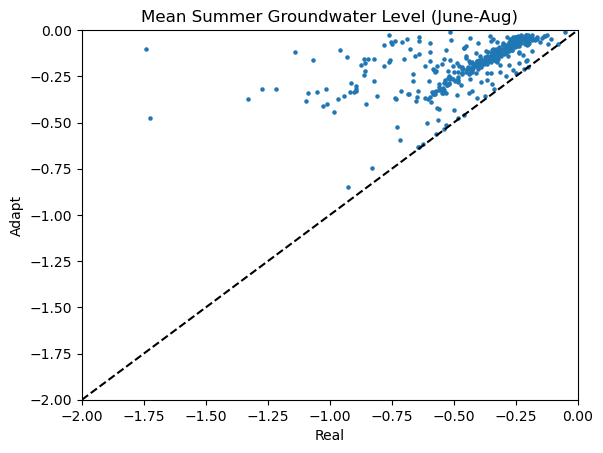

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(real_mean, adapt_mean, s=5)
plt.axline((0, 0), slope=1, linestyle='--', color='black')  # 1:1 line
plt.xlabel("Real")
plt.ylabel("Adapt")
plt.title("Mean Summer Groundwater Level (June-Aug)")
plt.ylim([-2.,0.])
plt.xlim([-2.,0.])
plt.show()

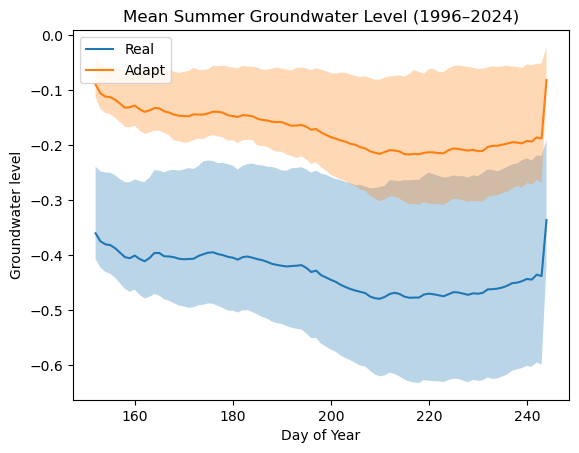

In [38]:
import matplotlib.pyplot as plt

# x-axis (day of year)
x = real_clim['dayofyear'].values

plt.figure()

# --- Real ---
plt.plot(x, real_clim.values, label="Real")
plt.fill_between(
    x,
    real_clim_low.values,
    real_clim_high.values,
    alpha=0.3
)

# --- Adapt ---
plt.plot(x, adapt_clim.values, label="Adapt")
plt.fill_between(
    x,
    adapt_clim_low.values,
    adapt_clim_high.values,
    alpha=0.3
)

plt.legend()
plt.title("Mean Summer Groundwater Level (1996–2024)")
plt.ylabel("Groundwater level")
plt.xlabel("Day of Year")
plt.show()